# Install and import

In [1]:
!pip install torch-geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

from datetime import timedelta

import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATv2Conv
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve





# Data - 5elem

## UNSW1

In [87]:
data_unsw1 = pd.read_csv('/content/UNSW-NB15_1.csv', dtype={'sport': object, 'dsport': object}, low_memory=False)

columnas = [
    "srcip", "sport", "dstip", "dsport", "proto", "state", "dur", "sbytes", "dbytes", "sttl",
    "dttl", "sloss", "dloss", "service", "sload", "dload", "spkts", "dpkts", "swin", "dwin",
    "stcpb", "dtcpb", "smeansz", "dmeansz", "trans_depth", "res_bdy_len", "sjit", "djit",
    "stime", "ltime", "sintpkt", "dintpkt", "tcprtt", "synack", "ackdat", "is_sm_ips_ports",
    "ct_state_ttl", "ct_flw_http_mthd", "is_ftp_login", "ct_ftp_cmd", "ct_srv_src", "ct_srv_dst",
    "ct_dst_ltm", "ct_src_ltm", "ct_src_dport_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm",
    "attack_cat", "label"
]

data_unsw1.columns = columnas


# Convert 'stime' and 'ltime' to datetime format
data_unsw1['stime'] = pd.to_datetime(data_unsw1['stime'], unit='s')
data_unsw1['ltime'] = pd.to_datetime(data_unsw1['ltime'], unit='s')


# Filter connections lasting less than a second
filtered_unsw1 = data_unsw1[(data_unsw1['dur']>0) & (data_unsw1['dur'] <= 1)]


# Filter connections from the first 110 minutes (that's where there are malicios connections)
# And select columns of interest
start_time = data_unsw1['stime'].min()
end_time = start_time + timedelta(minutes=110)

unsw1_sub = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','spkts','dpkts','stime','ltime','label']].drop_duplicates()

# Drop rows with NaN values (i.e., missing ports)
unsw1_sub.replace('-', pd.NA, inplace=True)
unsw1 = unsw1_sub.dropna()

In [151]:
data_unsw1.duplicated().sum()

59213

In [152]:
unsw1_sub_NOdrop = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','spkts','dpkts','stime','ltime','label']]
unsw1_sub_NOdrop.duplicated().sum()

19

In [153]:
unsw1_sub_drop = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','spkts','dpkts','stime','ltime','label']].drop_duplicates()
unsw1_sub_drop.duplicated().sum()

0

In [154]:
unsw1.duplicated().sum()

0

In [ ]:
# from sklearn.preprocessing import MinMaxScaler

# # Seleccionar las características a normalizar
# features_to_normalize = ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']

# # Crear un objeto MinMaxScaler
# scaler = MinMaxScaler()

# # Ajustar y transformar las características
# unsw1[features_to_normalize] = scaler.fit_transform(unsw1[features_to_normalize])

# # Verificar resultados
# print(unsw1[features_to_normalize].describe())

In [ ]:
unsw1.keys()

Index(['srcip', 'sport', 'dstip', 'dsport', 'proto', 'dur', 'sbytes', 'dbytes',
       'spkts', 'dpkts', 'stime', 'ltime', 'label'],
      dtype='object')

<ipython-input-60-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


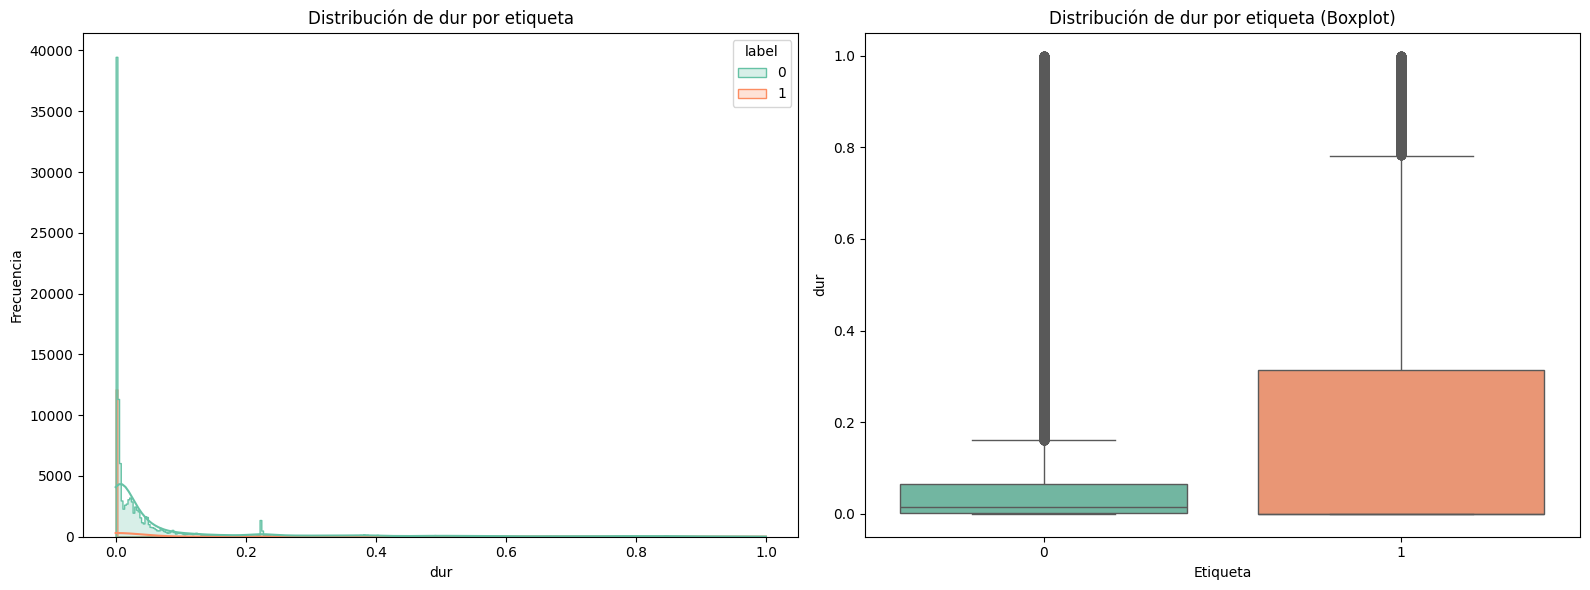

<ipython-input-60-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


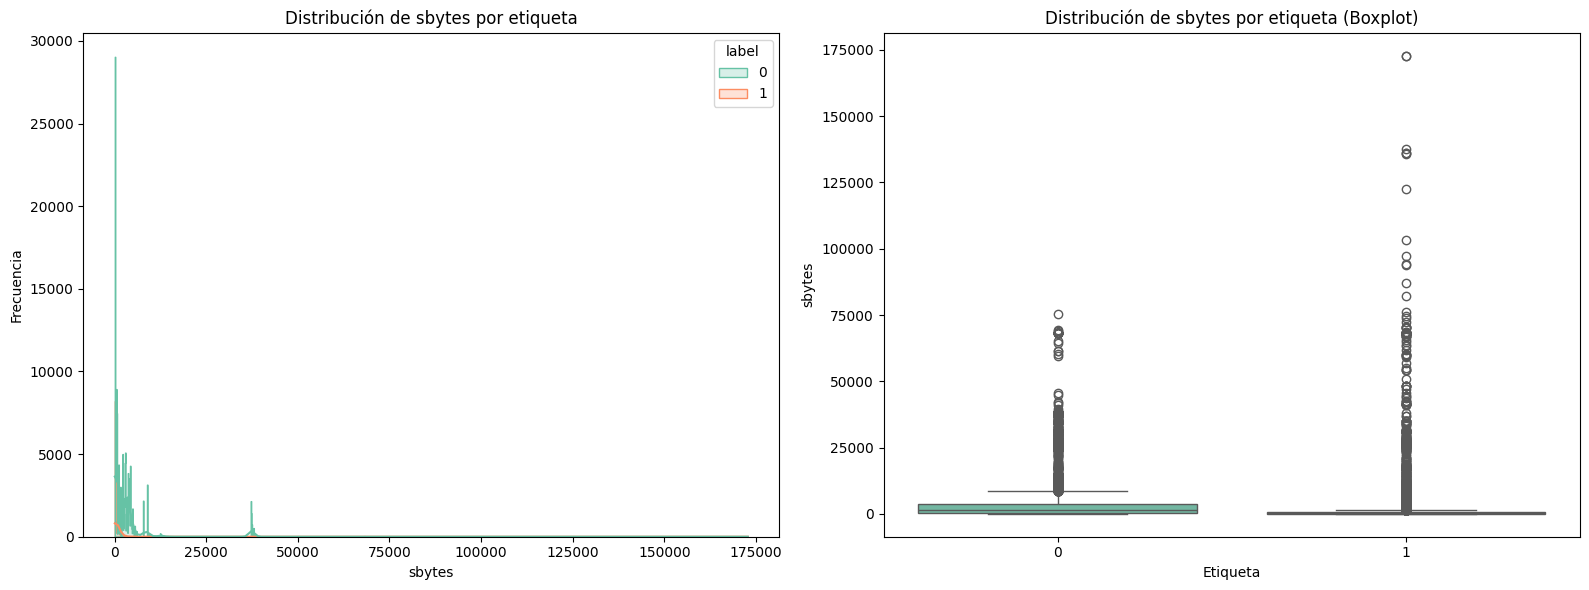

<ipython-input-60-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


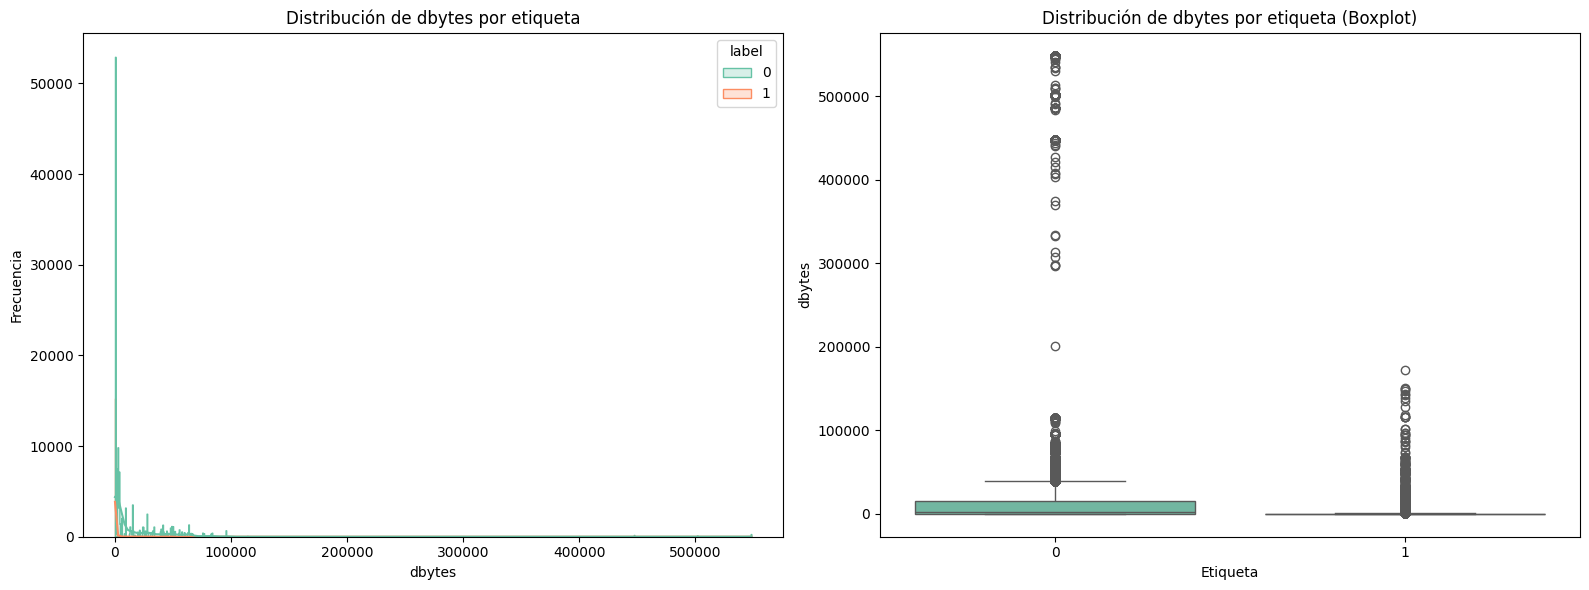

<ipython-input-60-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


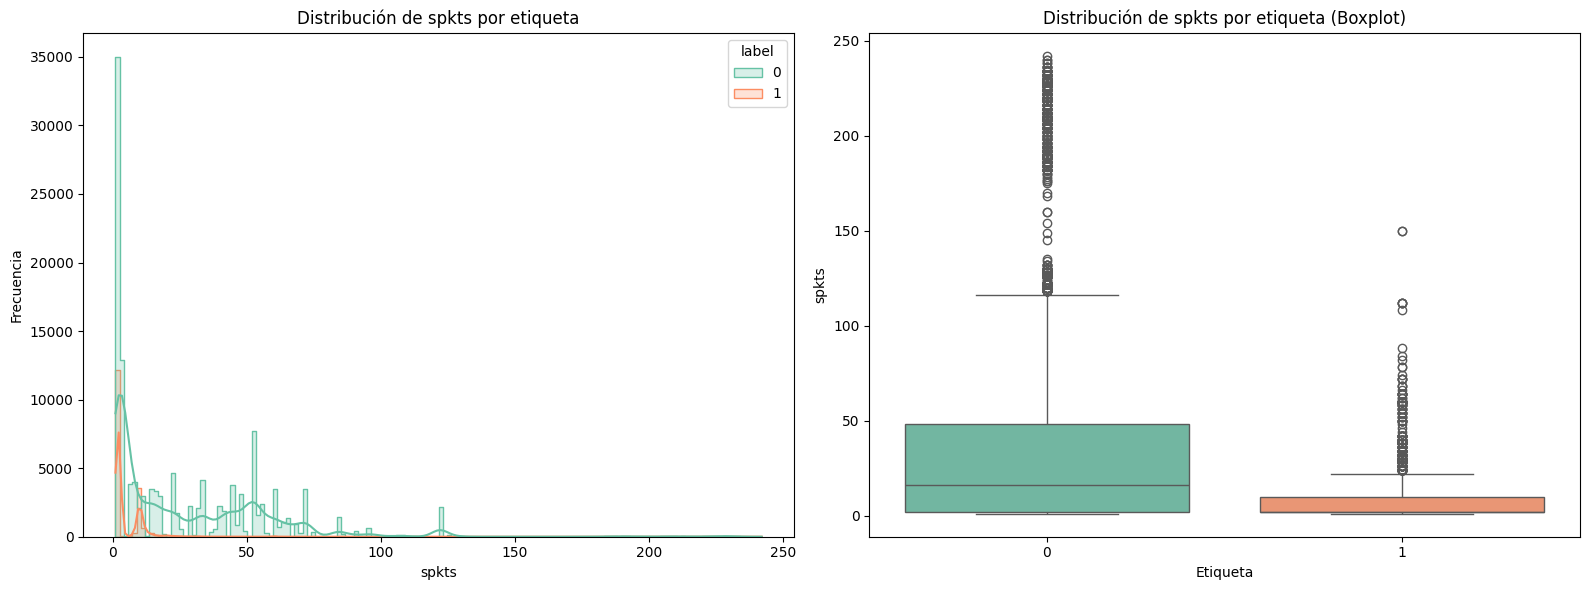

<ipython-input-60-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


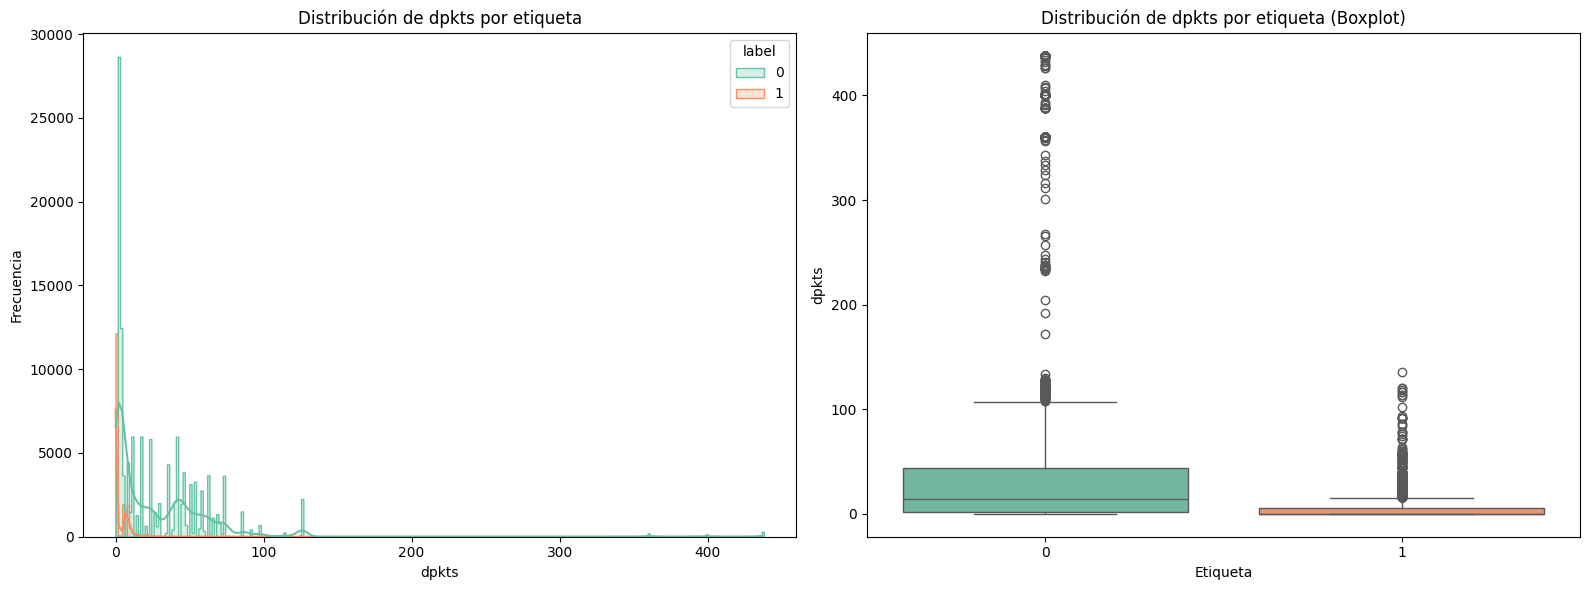

Resumen estadístico de características por etiqueta:
label                     0              1
dur    count  129638.000000   17583.000000
       mean        0.095572       0.175556
       std         0.191167       0.292284
       min         0.000001       0.000001
       25%         0.001133       0.000006
       50%         0.015694       0.000011
       75%         0.065296       0.313004
       max         0.999911       0.999796
sbytes count  129638.000000   17583.000000
       mean     3707.852713    1205.460957
       std      7646.479198    6260.903199
       min        52.000000      60.000000
       25%       264.000000     114.000000
       50%      1540.000000     200.000000
       75%      3614.000000     662.000000
       max     75496.000000  172777.000000
dbytes count  129638.000000   17583.000000
       mean    15315.718192     925.854291
       std     41318.436394    6325.192980
       min         0.000000       0.000000
       25%       178.000000       0.000000
 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Crear un DataFrame temporal para análisis
snapshot_data = unsw1.copy()  # Asegúrate de usar el conjunto preprocesado `unsw1`

# Seleccionar columnas relevantes
features_to_plot = ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']  # Características más importantes
labels = snapshot_data['label']  # Etiqueta

# Crear histogramas y boxplots por característica y etiqueta
for feature in features_to_plot:
    plt.figure(figsize=(16, 6))

    # Histograma
    plt.subplot(1, 2, 1)
    sns.histplot(data=snapshot_data, x=feature, hue='label', kde=True, palette='Set2', element='step')
    plt.title(f'Distribución de {feature} por etiqueta')
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')
    plt.title(f'Distribución de {feature} por etiqueta (Boxplot)')
    plt.xlabel('Etiqueta')
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

# Resumen estadístico
print("Resumen estadístico de características por etiqueta:")
summary_stats = snapshot_data.groupby('label')[features_to_plot].describe().transpose()
print(summary_stats)


### Option 1: Nodes = (ip, port)

In [ ]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3) # Snapshots every 3 minutes

start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()  # Limpia espacios en 'ip'
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()  # Asegura que 'port' es cadena
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport']).agg({        # AGREGO puerto, pero no se como considerar el protocolo
        'spkts': 'mean',
        'sbytes': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport']).agg({        # AGREGO puerto, pero no se como considerar el protocolo
        'dpkts': 'mean',
        'dbytes': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        #'sbytes': 'mean',
        #'dbytes': 'mean',
        #'spkts': 'mean',
        #'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    #edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot

#graph_snapshots = {i: Data(x=node_features_pad, edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}
torch_geo_graphs_unsw1 = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

### Option 2: Nodes = (ip,port,proto) - Features de los edges

In [ ]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport','proto']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    # src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
    #     'spkts': 'mean',
    #     'sbytes': 'mean'
    # }).reset_index()
    # src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    # src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    # dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
    #     'dpkts': 'mean',
    #     'dbytes': 'mean'
    # }).reset_index()
    # dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    # dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    # nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    # nodes_features = nodes_features[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    # nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)

    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        'sbytes': 'mean',
        'dbytes': 'mean',
        'spkts': 'mean',
        'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    #edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    #node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [ ]:
torch_geo_graphs_unsw1_proto

{0: Data(x=[4451, 1], edge_index=[2, 3279], edge_attr=[3279, 5], y=[3279]),
 1: Data(x=[4843, 1], edge_index=[2, 3532], edge_attr=[3532, 5], y=[3532]),
 2: Data(x=[4764, 1], edge_index=[2, 3570], edge_attr=[3570, 5], y=[3570]),
 3: Data(x=[5494, 1], edge_index=[2, 4187], edge_attr=[4187, 5], y=[4187]),
 4: Data(x=[5688, 1], edge_index=[2, 4376], edge_attr=[4376, 5], y=[4376]),
 5: Data(x=[4931, 1], edge_index=[2, 3554], edge_attr=[3554, 5], y=[3554]),
 6: Data(x=[5456, 1], edge_index=[2, 3971], edge_attr=[3971, 5], y=[3971]),
 7: Data(x=[5042, 1], edge_index=[2, 3605], edge_attr=[3605, 5], y=[3605]),
 8: Data(x=[4898, 1], edge_index=[2, 3414], edge_attr=[3414, 5], y=[3414]),
 9: Data(x=[4794, 1], edge_index=[2, 3300], edge_attr=[3300, 5], y=[3300]),
 10: Data(x=[4771, 1], edge_index=[2, 3333], edge_attr=[3333, 5], y=[3333]),
 11: Data(x=[4908, 1], edge_index=[2, 3379], edge_attr=[3379, 5], y=[3379]),
 12: Data(x=[5495, 1], edge_index=[2, 3664], edge_attr=[3664, 5], y=[3664]),
 13: Data

### Option 2': Nodes = (ip, port, proto) - Features de los nodos

In [174]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport','proto']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        #'sbytes': 'mean',
        #'dbytes': 'mean',
        #'spkts': 'mean',
        #'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    #edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [175]:
div_prop=0
for i in range(len(torch_geo_graphs_unsw1_proto)):
  sum_norm=0
  sum_bot=0
  for j in range(len(torch_geo_graphs_unsw1_proto[i].y)):
    if torch_geo_graphs_unsw1_proto[i].y[j]==0:
      sum_norm+=1
    else:
      sum_bot+=1
  div_prop+= (sum_norm/sum_bot)
  print(i,sum_norm,sum_bot,sum_norm/sum_bot)

print(div_prop/36)

0 3117 162 19.24074074074074
1 3235 297 10.892255892255893
2 3386 184 18.402173913043477
3 4119 68 60.5735294117647
4 4247 129 32.92248062015504
5 3371 183 18.420765027322403
6 3795 176 21.5625
7 3343 262 12.759541984732824
8 3239 175 18.50857142857143
9 3093 207 14.942028985507246
10 3149 184 17.11413043478261
11 3142 237 13.257383966244726
12 3443 221 15.57918552036199
13 3422 210 16.295238095238094
14 3621 190 19.057894736842105
15 3558 197 18.060913705583758
16 3362 170 19.776470588235295
17 3406 177 19.242937853107346
18 3233 339 9.536873156342184
19 3239 178 18.196629213483146
20 3191 236 13.521186440677965
21 3300 198 16.666666666666668
22 3337 168 19.863095238095237
23 3311 169 19.59171597633136
24 3300 178 18.53932584269663
25 3403 183 18.595628415300546
26 3087 226 13.65929203539823
27 3133 205 15.282926829268293
28 3174 187 16.97326203208556
29 3198 210 15.228571428571428
30 3377 176 19.1875
31 3758 132 28.46969696969697
32 3288 103 31.92233009708738
33 3318 173 19.179190751

In [ ]:
pairs1 = set(tuple(pair) for pair in torch_geo_graphs_unsw1_proto[1].edge_index.T.tolist())

for i in range(len(torch_geo_graphs_unsw1_proto)):
  pairs2 = set(tuple(pair) for pair in torch_geo_graphs_unsw1_proto[i].edge_index.T.tolist())
  print(i,len(pairs1.intersection(pairs2)),len(pairs1.intersection(pairs2))/len(torch_geo_graphs_unsw1_proto[i].y))

0 3 0.0011337868480725624
1 3506 1.0
2 2 0.0005691519635742744
3 6 0.001444043321299639
4 6 0.0013901760889712697
5 11 0.002906208718626156
6 8 0.002037178507766743
7 6 0.001669449081803005
8 4 0.0011444921316165952
9 7 0.0021766169154228856
10 7 0.0020558002936857563
11 8 0.0023937761819269898
12 4 0.0010931948619841486
13 2 0.0005505092210294523
14 5 0.0013631406761177754
15 5 0.0012807377049180327
16 5 0.0014040999719180005
17 2 0.0005515719801434088
18 1 0.0002796420581655481
19 3 0.0008698173383589446
20 3 0.0008743806470416788
21 4 0.0011467889908256881
22 4 0.0011379800853485065
23 6 0.0017266187050359713
24 7 0.0019875070982396364
25 2 0.0005538631957906397
26 8 0.0024002400240024004
27 3 0.0008920606601248885
28 3 0.0008965929468021519
29 5 0.001457301078402798
30 5 0.0014273479874393378
31 3 0.000794912559618442
32 3 0.0008408071748878924
33 2 0.0005765350245027386
34 9 0.002563372258615779
35 2 0.0005720823798627002


#### Breve exploracion del preprocesamiento

In [138]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

node_features_orig = []
pair_to_index_list = []
src_features_list = []
dst_features_list = []
edge_attr_list = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport','proto']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features_orig = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')

    nodes_features = nodes_features_orig[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        #'sbytes': 'mean',
        #'dbytes': 'mean',
        #'spkts': 'mean',
        #'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    #edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    node_features_orig.append(nodes_features_orig)
    pair_to_index_list.append(pair_to_index)
    src_features_list.append(src_features)
    dst_features_list.append(dst_features)
    edge_attr_list.append(edge_attr)


    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [116]:
torch_geo_graphs_unsw1_proto[0]

Data(x=[4451, 4], edge_index=[2, 3279], edge_attr=[3279, 1], y=[3279])

In [117]:
inverted_dict = {v: k for k, v in pair_to_index_list[0].items()}

In [118]:
for i in range(len(labels[0])):
  srcip,sport,proto = inverted_dict[int(edge_indices[0][0,i])].split(',')
  dstip,dsport,proto1 = inverted_dict[int(edge_indices[0][1,i])].split(',')
  assert proto==proto1, 'not same protocol'
  if len(unsw1[(unsw1['srcip']==srcip) & (unsw1['sport']==sport) & (unsw1['dstip']==dstip) & (unsw1['dsport']==dsport)])>1:
    print(i)

692
2389
2446
2508


In [134]:
edge_indices[0][:,2389]

tensor([3561,  619])

In [135]:
print(inverted_dict[3561])
print(inverted_dict[619])

59.166.0.7,1133,udp
149.171.126.4,53,udp


In [136]:
unsw1[(unsw1['srcip']=='59.166.0.7') & (unsw1['sport']=='1133') & (unsw1['proto']=='udp')]

,srcip,sport,dstip,dsport,proto,dur,sbytes,dbytes,spkts,dpkts,stime,ltime,label
4218,59.166.0.7,1133,149.171.126.4,53,udp,0.000893,130,162,2,2,2015-01-22 11:52:42,2015-01-22 11:52:42,0
142099,59.166.0.7,1133,149.171.126.4,53,udp,0.001065,146,178,2,2,2015-01-22 13:18:00,2015-01-22 13:18:00,0


In [122]:
unsw1[(unsw1['dstip']=='59.166.0.7') & (unsw1['dsport']=='1133') & (unsw1['proto']=='udp')]

,srcip,sport,dstip,dsport,proto,dur,sbytes,dbytes,spkts,dpkts,stime,ltime,label


In [139]:
node_features_orig[0].iloc[3561,:]

,3561
src_pairs,"59.166.0.7,1133,udp"
srcip,59.166.0.7
sport,1133
proto_x,udp
spkts,2.0
sbytes,130.0
dst_pairs,"59.166.0.7,1133,udp"
dstip,0
dsport,0
proto_y,0


In [143]:
node_features[0][3561,:]

tensor([  2., 130.,   0.,   0.])

In [146]:
edge_attr_list[0].iloc[2389,:]

,2389
srcip,59.166.0.7
sport,1133
proto,udp
dstip,149.171.126.4
dsport,53
dur,0.000893
label,0
src_pairs,"59.166.0.7,1133,udp"
dst_pairs,"149.171.126.4,53,udp"


In [149]:
edge_features[0][2389]

tensor([0.0009])

In [124]:
aux = unsw1[(unsw1['srcip']=='59.166.0.7') & (unsw1['sport']=='1133') & (unsw1['proto']=='udp')]

aux.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean'
}).reset_index()

,srcip,sport,proto,spkts,sbytes
0,59.166.0.7,1133,udp,2.0,138.0


In [106]:
unsw1[(unsw1['srcip']=='59.166.0.7') & (unsw1['sport']=='1133') & (unsw1['proto']=='udp')]

,srcip,sport,dstip,dsport,proto,dur,sbytes,dbytes,spkts,dpkts,stime,ltime,label
4218,59.166.0.7,1133,149.171.126.4,53,udp,0.000893,130,162,2,2,2015-01-22 11:52:42,2015-01-22 11:52:42,0
142099,59.166.0.7,1133,149.171.126.4,53,udp,0.001065,146,178,2,2,2015-01-22 13:18:00,2015-01-22 13:18:00,0


In [140]:
pair_to_index_list[0]['59.166.0.7,1133,udp']

3561

In [150]:
labels[0][2389]

tensor(0)

#### Armando pair_to_index considerando todos los nodos del grafo, no por snapshot

El tensor `x` tiene shape [172471, 4] para todos los snapshots, porque se completan con 0s las features de aquellos nodos que no aparecen en el snapshot. Esto podría causar ruido... demasiados ceros...

Quizás se podrían usar máscaras.

In [155]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot

src = unsw1[['srcip', 'sport','proto']].copy()
src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

dst = unsw1[['dstip', 'dsport','proto']].copy()
dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

unique_pairs = pd.concat([src,dst]).drop_duplicates()
unique_pairs['ip'] = unique_pairs['ip'].str.strip()
unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    # src = snapshot_data[['srcip', 'sport','proto']].copy()
    # src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    # dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    # dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    # unique_pairs = pd.concat([src,dst]).drop_duplicates()
    # unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    # unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    # unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    # unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    # unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    # unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    # pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        #'sbytes': 'mean',
        #'dbytes': 'mean',
        #'spkts': 'mean',
        #'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    #edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [170]:
torch_geo_graphs_unsw1_proto

{0: Data(x=[172471, 4], edge_index=[2, 3279], edge_attr=[3279, 1], y=[3279]),
 1: Data(x=[172471, 4], edge_index=[2, 3532], edge_attr=[3532, 1], y=[3532]),
 2: Data(x=[172471, 4], edge_index=[2, 3570], edge_attr=[3570, 1], y=[3570]),
 3: Data(x=[172471, 4], edge_index=[2, 4187], edge_attr=[4187, 1], y=[4187]),
 4: Data(x=[172471, 4], edge_index=[2, 4376], edge_attr=[4376, 1], y=[4376]),
 5: Data(x=[172471, 4], edge_index=[2, 3554], edge_attr=[3554, 1], y=[3554]),
 6: Data(x=[172471, 4], edge_index=[2, 3971], edge_attr=[3971, 1], y=[3971]),
 7: Data(x=[172471, 4], edge_index=[2, 3605], edge_attr=[3605, 1], y=[3605]),
 8: Data(x=[172471, 4], edge_index=[2, 3414], edge_attr=[3414, 1], y=[3414]),
 9: Data(x=[172471, 4], edge_index=[2, 3300], edge_attr=[3300, 1], y=[3300]),
 10: Data(x=[172471, 4], edge_index=[2, 3333], edge_attr=[3333, 1], y=[3333]),
 11: Data(x=[172471, 4], edge_index=[2, 3379], edge_attr=[3379, 1], y=[3379]),
 12: Data(x=[172471, 4], edge_index=[2, 3664], edge_attr=[3664

In [156]:
pairs1 = set(tuple(pair) for pair in torch_geo_graphs_unsw1_proto[0].edge_index.T.tolist())

for i in range(len(torch_geo_graphs_unsw1_proto)):
  pairs2 = set(tuple(pair) for pair in torch_geo_graphs_unsw1_proto[i].edge_index.T.tolist())
  print(i,len(pairs1.intersection(pairs2)),len(pairs1.intersection(pairs2))/len(torch_geo_graphs_unsw1_proto[i].y))

0 3279 1.0
1 0 0.0
2 0 0.0
3 0 0.0
4 0 0.0
5 0 0.0
6 0 0.0
7 0 0.0
8 0 0.0
9 0 0.0
10 0 0.0
11 0 0.0
12 0 0.0
13 1 0.00027533039647577095
14 0 0.0
15 0 0.0
16 0 0.0
17 0 0.0
18 0 0.0
19 0 0.0
20 0 0.0
21 0 0.0
22 0 0.0
23 1 0.00028735632183908046
24 0 0.0
25 0 0.0
26 0 0.0
27 0 0.0
28 1 0.0002975304968759298
29 1 0.00029342723004694836
30 0 0.0
31 0 0.0
32 0 0.0
33 0 0.0
34 0 0.0
35 0 0.0


# Models

## GNN traditional

In [172]:
class GNN_traditional(torch.nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2):
        super(GNN_traditional, self).__init__()
        self.conv1 = SAGEConv(node_input_dim, hidden_dim1)
        self.conv2 = SAGEConv(hidden_dim1, hidden_dim2)
        #self.conv1 = GCNConv(node_input_dim, hidden_dim1)
        #self.conv2 = GCNConv(hidden_dim1, hidden_dim2)
        self.fc = torch.nn.Linear(hidden_dim2 * 2 + edge_input_dim, 1)  # Combine both nodes + edge_attr

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        #print(f"input:{x.shape}")
          # x is shape (num_nodes_in_snapshot, node_input_dim)

        x = self.conv1(x, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
        #print(f"x after first gnn:{x.shape}")
        x = self.conv2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)
        #print(f"x after seconf gnn:{x.shape}")

        # Combine node representations with edge features
        src_nodes = edge_index[0]  # Source nodes of edges
        dst_nodes = edge_index[1]  # Destination nodes of edges
        edge_features = torch.cat([x[src_nodes], x[dst_nodes], edge_attr], dim=1) # (num_edges_in_snapshot, 2*hidden_dim2 + edge_input_dim)
        #print(f"edge_features:{edge_features.shape}")

        predictions = self.fc(edge_features)
        #print(f"predictions:{predictions.shape}")

        return predictions#, edge_features





# Train and test

In [158]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Model 1: traditional

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1 = GNN_traditional(node_input_dim=4, edge_input_dim=1, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.01)
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)


#ratio_neg_to_pos = 2
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = list(range(28)) #30
val_windows = list(range(31,36))#28,36)) #30,39


# Train
epochs = 75
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        optimizer.zero_grad()
        out = model1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    model1.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m1, all_labels_m1 = [], []
    with torch.no_grad():
        for window in val_windows:
            data = torch_geo_graphs_unsw1_proto[window].to(device)
            out = model1(data)
            loss = criterion(out.squeeze(), data.y.to(device).float())
            probabilities = torch.sigmoid(out)
            preds = (probabilities.view(-1) > 0.4).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = data.y.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m1.extend(preds)
            all_labels_m1.extend(data.y.cpu().numpy())
    val_loss_final = val_loss / total_val_edges #len(val_windows)
    val_losses_m1.append(val_loss_final)
    roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/75, Train Loss: 100.9829, Val Loss: 27.8285, , Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 2/75, Train Loss: 33.2092, Val Loss: 20.8446, , Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 3/75, Train Loss: 43.9212, Val Loss: 12.9000, , Current LR: 0.010000, ROC-AUC: 0.5093430144140083, F1:0.03722084367245657
Epoch 4/75, Train Loss: 27.6927, Val Loss: 7.5220, , Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 5/75, Train Loss: 12.4660, Val Loss: 3.4072, , Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 6/75, Train Loss: 6.2930, Val Loss: 4.6870, , Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 7/75, Train Loss: 6.0095, Val Loss: 1.3741, , Current LR: 0.010000, ROC-AUC: 0.531372142934009, F1:0.10756040530007795
Epoch 8/75, Train Loss: 5.5477, Val Loss: 6.0957, , Current LR: 0.010000, ROC-AUC: 0.7183623786057863, F1:0.2966131907308378
Epoch 9/75, Train Loss: 15.0387, Val Loss: 2.9860, , Current LR: 0.010000, ROC-AUC: 0.5294269929158367, F1:0.10304449648711944
Epoch 10/75, 

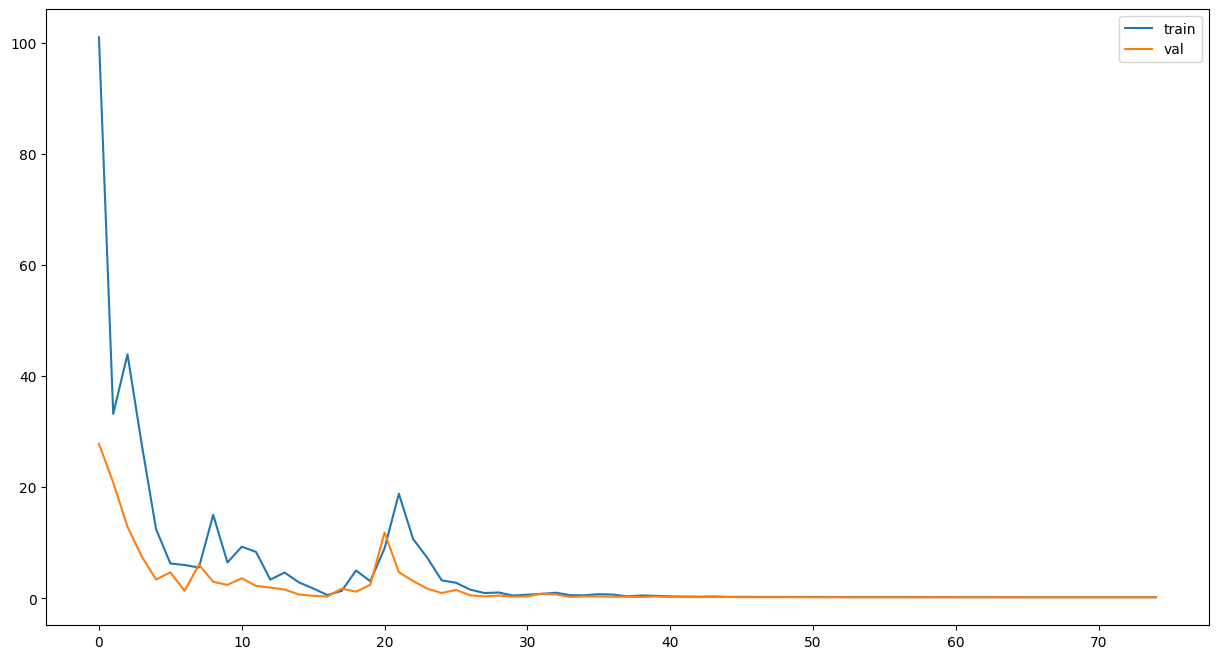

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(75), train_losses_m1, label="train")
axs.plot(range(75), val_losses_m1, label="val")
axs.legend()

In [ ]:
# Evaluación training set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
with torch.no_grad():
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        out = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")



ROC-AUC: 0.6757
Accuracy: 0.9403
Precision: 0.4495
Recall: 0.3785
F1: 0.4110


In [162]:
# Evaluación validation set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
with torch.no_grad():
    for window in val_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        out = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")



ROC-AUC: 0.6530
Accuracy: 0.9398
Precision: 0.3248
Recall: 0.3384
F1: 0.3315


### Training with 2 graphs

In [177]:
torch_geo_graphs_unsw1_proto[1]

Data(x=[4843, 4], edge_index=[2, 3532], edge_attr=[3532, 1], y=[3532])

In [176]:
torch_geo_graphs_unsw1_proto[18]

Data(x=[5354, 4], edge_index=[2, 3572], edge_attr=[3572, 1], y=[3572])

In [201]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1 = GNN_traditional(node_input_dim=4, edge_input_dim=1, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.01)

#scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)


#ratio_neg_to_pos = 2
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = [18] #list(range(28)) #30
#val_windows = list(range(31,36))#28,36)) #30,39


# Train
epochs = 250
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        optimizer.zero_grad()
        out = model1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    # model1.eval()
    # val_loss = 0
    # total_val_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    # with torch.no_grad():
    #     for window in val_windows:
    #         data = torch_geo_graphs_unsw1_proto[window].to(device)
    #         out = model1(data)
    #         loss = criterion(out.squeeze(), data.y.to(device).float())
    #         probabilities = torch.sigmoid(out)
    #         preds = (probabilities.view(-1) > 0.4).long()
    #         # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
    #         num_edges = data.y.size(0)
    #         val_loss += loss.item() * num_edges
    #         total_val_edges += num_edges
    #         all_preds_m1.extend(preds)
    #         all_labels_m1.extend(data.y.cpu().numpy())
    # val_loss_final = val_loss / total_val_edges #len(val_windows)
    # val_losses_m1.append(val_loss_final)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # # Actualizar el scheduler
    # scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}")#, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/250, Train Loss: 281.1042
Epoch 2/250, Train Loss: 30.7423
Epoch 3/250, Train Loss: 41.9378
Epoch 4/250, Train Loss: 49.2934
Epoch 5/250, Train Loss: 53.9278
Epoch 6/250, Train Loss: 56.4400
Epoch 7/250, Train Loss: 57.2287
Epoch 8/250, Train Loss: 56.5918
Epoch 9/250, Train Loss: 54.7674
Epoch 10/250, Train Loss: 51.9512
Epoch 11/250, Train Loss: 48.3070
Epoch 12/250, Train Loss: 43.9959
Epoch 13/250, Train Loss: 39.2169
Epoch 14/250, Train Loss: 34.4631
Epoch 15/250, Train Loss: 30.0025
Epoch 16/250, Train Loss: 49.4476
Epoch 17/250, Train Loss: 30.2295
Epoch 18/250, Train Loss: 34.5421
Epoch 19/250, Train Loss: 38.4173
Epoch 20/250, Train Loss: 41.8701
Epoch 21/250, Train Loss: 44.5592
Epoch 22/250, Train Loss: 46.5801
Epoch 23/250, Train Loss: 47.9573
Epoch 24/250, Train Loss: 48.7388
Epoch 25/250, Train Loss: 48.9833
Epoch 26/250, Train Loss: 48.7461
Epoch 27/250, Train Loss: 48.0793
Epoch 28/250, Train Loss: 47.0320
Epoch 29/250, Train Loss: 45.6503
Epoch 30/250, Train Lo

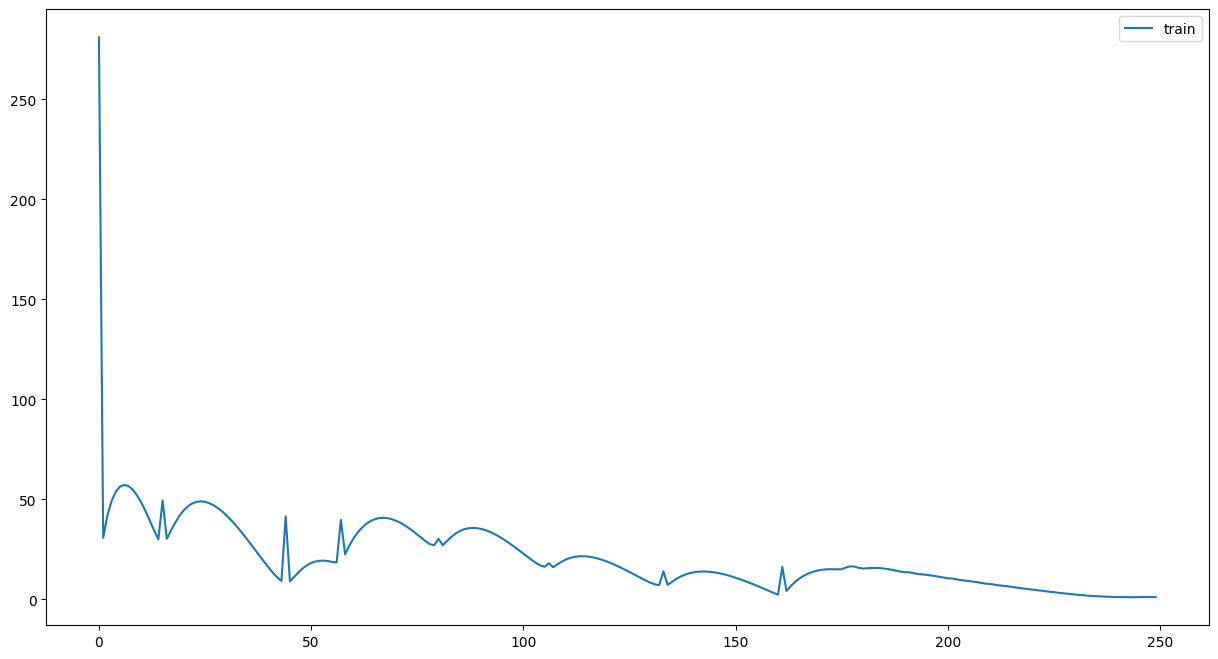

In [202]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(250), train_losses_m1, label="train")
axs.legend()

In [203]:
# Evaluación training set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
with torch.no_grad():
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        out = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")



ROC-AUC: 0.6651
Accuracy: 0.7284
Precision: 0.1934
Recall: 0.5870
F1: 0.2909
